## Authors:

Bilca Maria (DS, Group 411)

Arabagiu Tudor-Gabriel (DS, Group 411)

Holmanu Antonio-Marius (AI, Group 407)

## IMPORTS & SETUP

In [1]:
import os
import re
import random
import time
import shutil
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import unicodedata
import joblib
import traceback

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset as HFDataset

# Download necessary NLTK resources (stopwords, lemmatizer data)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Configuration: Seed for reproducibility
SEED = 42

def set_seed(seed):
    """Sets the seed for random number generators in Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Setup complete. Running on device: {DEVICE}")

# Create a directory to store trained models permanently (or until session ends)
MODELS_DIR = "/kaggle/working/saved_models"
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

# Define file paths
SEMEVAL_TRAIN_PATH = "/kaggle/input/semeval-2018-task-ec/2018-E-c-En-train.txt"
SEMEVAL_DEV_PATH = "/kaggle/input/semeval-2018-task-ec/2018-E-c-En-dev.txt"
DELL_DATASET_PATH = "/kaggle/input/sentiment-and-emotions-of-tweets/sentiment-emotion-labelled_Dell_tweets.csv"

2026-01-24 14:45:34.657802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769265934.834419      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769265934.886141      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769265935.318860      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769265935.318894      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769265935.318896      55 computation_placer.cc:177] computation placer alr

Setup complete. Running on device: cuda


## AUXILIARY FUNCTIONS

In [ ]:
def check_path_existence(path):
    """Check if a file exists"""
    if not os.path.exists(path):
        print(f"WARNING: Could not find {path}. Please check the path!")
        return False
    return True

def load_data(path, sep='\t'):
    """Load a CSV/TSV file into a DataFrame"""
    try:
        df = pd.read_csv(path, sep=sep, engine='python', on_bad_lines='error')
        return df
    except Exception as e:
        print(f"Error reading file {path}: {e}")
        return None

def inspect_df(df, name="DataFrame"):
    """Display basic info + a clean head of the table"""
    if df is None:
        print(f"{name} was not loaded.")
        return
    print(f"--- {name} ---")
    print(f"Number of rows: {len(df)}")
    print(f"Number of columns: {df.shape[1]}")
    print(f"Columns: {list(df.columns)}")
    print("Table head:")
    display(df.head())
    print("\n")

## READ DATASETS

In [3]:
# Check file existence 
for path in [SEMEVAL_TRAIN_PATH, SEMEVAL_DEV_PATH, DELL_DATASET_PATH]:
    if check_path_existence(path):
        print(f"Fișierul {path} există și poate fi încărcat.\n")

# Load datasets
df_semeval_raw_train = load_data(SEMEVAL_TRAIN_PATH, sep='\t')
df_semeval_raw_dev = load_data(SEMEVAL_DEV_PATH, sep='\t')
df_dell_raw = load_data(DELL_DATASET_PATH, sep=',')

# Visualise datasets
for df, name in zip([df_semeval_raw_train, df_semeval_raw_dev, df_dell_raw],
                    ["SEMEVAL Train", "SEMEVAL Dev", "Dell Dataset"]):
    inspect_df(df, name)

Fișierul /kaggle/input/semeval-2018-task-ec/2018-E-c-En-train.txt există și poate fi încărcat.

Fișierul /kaggle/input/semeval-2018-task-ec/2018-E-c-En-dev.txt există și poate fi încărcat.

Fișierul /kaggle/input/sentiment-and-emotions-of-tweets/sentiment-emotion-labelled_Dell_tweets.csv există și poate fi încărcat.

--- SEMEVAL Train ---
Număr rânduri: 6838
Număr coloane: 13
Coloane: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
Cap de tabel:


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-21441,“Worry is a down payment on a problem you may never have'. Joyce Meyer. #motivation #leadership #worry,0,1,0,0,0,0,1,0,0,0,1
1,2017-En-31535,Whatever you decide to do make sure it makes you #happy.,0,0,0,0,1,1,1,0,0,0,0
2,2017-En-21068,"@Max_Kellerman it also helps that the majority of NFL coaching is inept. Some of Bill O'Brien's play calling was wow, ! #GOPATS",1,0,1,0,1,0,1,0,0,0,0
3,2017-En-31436,Accept the challenges so that you can literally even feel the exhilaration of victory.' -- George S. Patton 🐶,0,0,0,0,1,0,1,0,0,0,0
4,2017-En-22195,My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs,1,0,1,0,0,0,0,0,0,0,0




--- SEMEVAL Dev ---
Număr rânduri: 886
Număr coloane: 13
Coloane: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
Cap de tabel:


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2018-En-00866,"@RanaAyyub @rajnathsingh Oh, hidden revenge and anger...I rememberthe time,she rebutted you.",1,0,1,0,0,0,0,0,0,0,0
1,2018-En-02590,I'm doing all this to make sure you smiling down on me bro,0,0,0,0,1,1,1,0,0,0,0
2,2018-En-03361,if not then #teamchristine bc all tana has done is provoke her by tweeting shady shit and trying to be a hard bitch begging for a fight,1,0,1,0,0,0,0,0,0,0,0
3,2018-En-03230,"It is a #great start for #beginners to jump into auto #trading. PROFITABLE FX EA will give you full support, manuals &amp; Team Viewer support.",0,0,0,0,1,0,1,0,0,0,0
4,2018-En-01143,My best friends driving for the first time with me in the car #terrifying,0,0,0,1,0,0,0,0,0,0,0




--- Dell Dataset ---
Număr rânduri: 24970
Număr coloane: 9
Coloane: ['Unnamed: 0', 'Datetime', 'Tweet Id', 'Text', 'Username', 'sentiment', 'sentiment_score', 'emotion', 'emotion_score']
Cap de tabel:


,Unnamed: 0,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
0,0,2022-09-30 23:29:15+00:00,1575991191170342912,"@Logitech @apple @Google @Microsoft @Dell @Lenovo #WhatIf QWERTY were modified for programmers so things like brackets, parens, quotes, operators, etc. moved to the middle near G-H splitting left/right brackets to separate hands, and relieving the less dextrous pinky finger?",ManjuSreedaran,neutral,0.853283,anticipation,0.587121
1,1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat @newzealand She's getting a new @Dell #laptop when the one she has one only 2-3 years old. (More than triple the price - though much higher utility). https://t.co/7WvkCw7vQf,MiKeMcDnet,neutral,0.519470,joy,0.886913
2,2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob Faletra and @stevenjburke spoke with me about the milestones, companies and personalities that helped build the channel. https://t.co/stiuBObP1O #CRN40 #podcast #internationalpodcastday @Cisco @Microsoft @HPE @hp @Dell @intel",jfollett,positive,0.763791,joy,0.960347
3,3,2022-09-30 20:05:24+00:00,1575939891485032450,@dell your customer service is horrible especially agent syedfaisal who has made this experience of purchasing a new computer downright awful and I’ll reconsider ever buying a Dell in the future @DellTech,daveccarr,negative,0.954023,anger,0.983203
4,4,2022-09-30 20:03:17+00:00,1575939359160750080,@zacokalo @Dell @DellCares @Dell give the man what he paid for!,heycamella,neutral,0.529170,anger,0.776124


## Exploratory Data Analysis

--- SemEval Train: Info and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6838 entries, 0 to 6837
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            6838 non-null   object
 1   Tweet         6838 non-null   object
 2   anger         6838 non-null   int64 
 3   anticipation  6838 non-null   int64 
 4   disgust       6838 non-null   int64 
 5   fear          6838 non-null   int64 
 6   joy           6838 non-null   int64 
 7   love          6838 non-null   int64 
 8   optimism      6838 non-null   int64 
 9   pessimism     6838 non-null   int64 
 10  sadness       6838 non-null   int64 
 11  surprise      6838 non-null   int64 
 12  trust         6838 non-null   int64 
dtypes: int64(11), object(2)
memory usage: 694.6+ KB

Missing values per column:


ID              0
Tweet           0
anger           0
anticipation    0
disgust         0
fear            0
joy             0
love            0
optimism        0
pessimism       0
sadness         0
surprise        0
trust           0
dtype: int64

--- Distribution of Emotions (SemEval Train) ---


anger           2544
anticipation     978
disgust         2602
fear            1242
joy             2477
love             700
optimism        1984
pessimism        795
sadness         2008
surprise         361
trust            357
dtype: int64

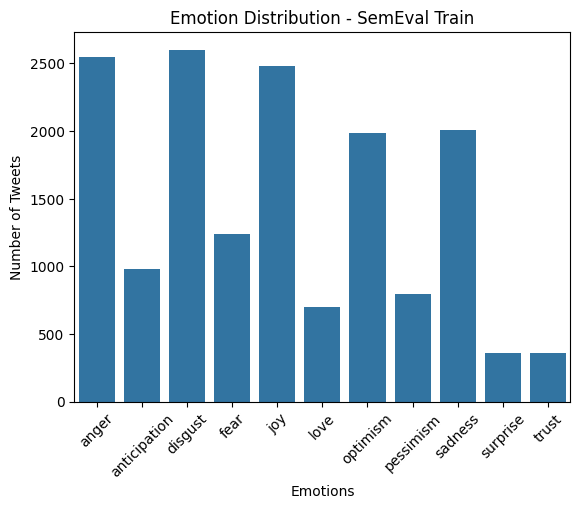

--- Combined Optimism/Pessimism Distribution (SemEval Train) ---


optimism  pessimism
0         0            4118
          1             736
1         0            1925
          1              59
dtype: int64

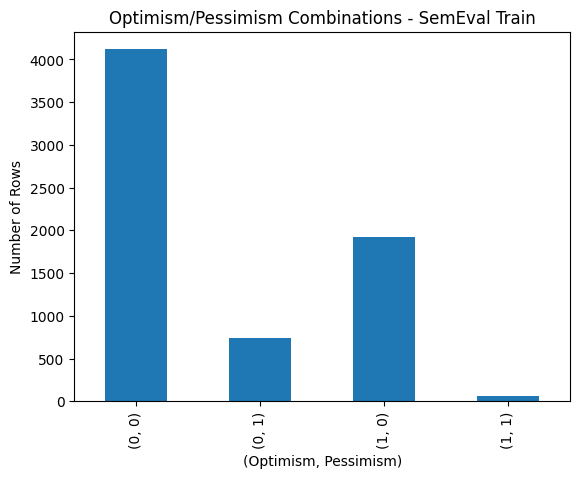

--- Dell Dataset: Info and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24970 entries, 0 to 24969
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       24970 non-null  int64  
 1   Datetime         24970 non-null  object 
 2   Tweet Id         24970 non-null  int64  
 3   Text             24970 non-null  object 
 4   Username         24970 non-null  object 
 5   sentiment        24970 non-null  object 
 6   sentiment_score  24970 non-null  float64
 7   emotion          24970 non-null  object 
 8   emotion_score    24970 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 1.7+ MB

Missing values per column:


Unnamed: 0         0
Datetime           0
Tweet Id           0
Text               0
Username           0
sentiment          0
sentiment_score    0
emotion            0
emotion_score      0
dtype: int64

--- Distribution of Emotions (Dell Dataset) ---


emotion
anger           7520
joy             6326
anticipation    5171
disgust         3000
sadness         1328
optimism        1225
fear             366
surprise          34
Name: count, dtype: int64

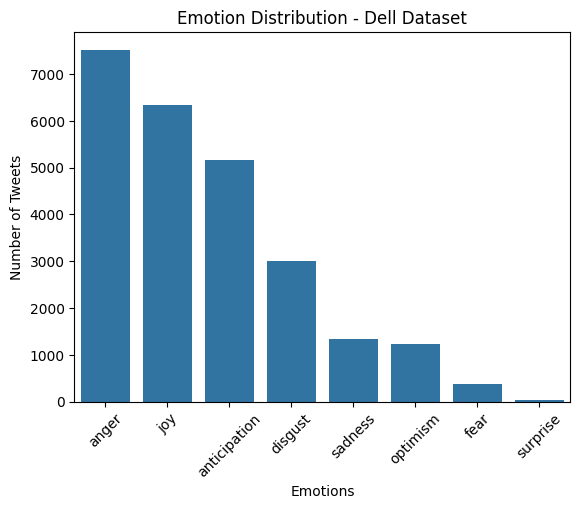


=== Emotion Percentages: Morning vs Evening (%) ===


time_period,Evening,Morning
emotion,,
anger,27.2,36.2
anticipation,21.1,19.1
disgust,11.6,11.5
fear,1.8,1.1
joy,28.1,21.4
optimism,5.1,5.1
sadness,4.8,5.5
surprise,0.2,0.1


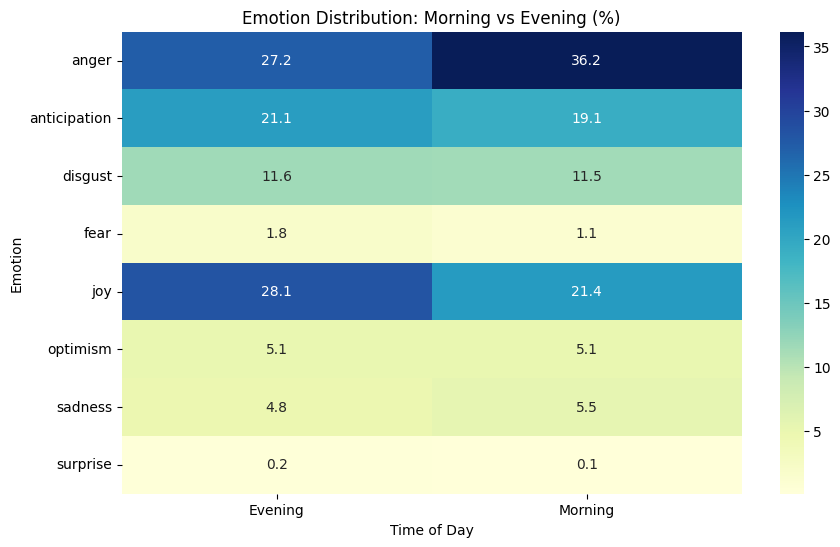

In [4]:
# --- SemEval Train EDA ---
print("--- SemEval Train: Info and Missing Values ---")
df_semeval_raw_train.info()
print("\nMissing values per column:")
display(df_semeval_raw_train.isna().sum())

# Distribution of emotions in SemEval Train
print("--- Distribution of Emotions (SemEval Train) ---")
semeval_emotion_cols = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love',
                            'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
emotion_counts = df_semeval_raw_train[semeval_emotion_cols].sum()
display(emotion_counts)

# Visualize emotion distribution
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title("Emotion Distribution - SemEval Train")
plt.xlabel("Emotions")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

# Combined distribution of Optimism/Pessimism in SemEval Train
if 'optimism' in df_semeval_raw_train.columns and 'pessimism' in df_semeval_raw_train.columns:
    combo_counts = df_semeval_raw_train.groupby(['optimism', 'pessimism']).size()
    print("--- Combined Optimism/Pessimism Distribution (SemEval Train) ---")
    display(combo_counts)

    combo_counts.plot(kind='bar', title="Optimism/Pessimism Combinations - SemEval Train")
    plt.xlabel("(Optimism, Pessimism)")
    plt.ylabel("Number of Rows")
    plt.show()

# --- Dell Dataset EDA ---
print("--- Dell Dataset: Info and Missing Values ---")
df_dell_raw.info()
print("\nMissing values per column:")
display(df_dell_raw.isna().sum())

# Distribution of emotions in Dell Dataset
print("--- Distribution of Emotions (Dell Dataset) ---")
display(df_dell_raw['emotion'].value_counts())

# Visualize emotion distribution
sns.countplot(
    x='emotion',
    data=df_dell_raw,
    order=df_dell_raw['emotion'].value_counts().index
)
plt.title("Emotion Distribution - Dell Dataset")
plt.xlabel("Emotions")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

# Emotions vs Time of Day in Dell Dataset
if 'Datetime' in df_dell_raw.columns and 'emotion' in df_dell_raw.columns:
    df_time = df_dell_raw.copy()

    # Convert to datetime
    df_time['Datetime'] = pd.to_datetime(df_time['Datetime'], errors='coerce')

    # Drop rows without valid datetime
    df_time = df_time.dropna(subset=['Datetime'])

    # Extract hour
    df_time['hour'] = df_time['Datetime'].dt.hour

    # Define time periods
    def get_time_of_day(hour):
        if 6 <= hour < 12:
            return 'Morning'
        elif 18 <= hour <= 23:
            return 'Evening'
        else:
            return 'Other'

    df_time['time_period'] = df_time['hour'].apply(get_time_of_day)

    # Filter for Morning and Evening
    time_df = df_time[df_time['time_period'].isin(['Morning', 'Evening'])]

    # Crosstab: Emotions vs Time of Day (percentages)
    emotion_time_stats = (
        pd.crosstab(
            time_df['emotion'],
            time_df['time_period'],
            normalize='columns'
        ) * 100
    )

    print("\n=== Emotion Percentages: Morning vs Evening (%) ===")
    display(emotion_time_stats.round(1))

    # Visualize heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        emotion_time_stats,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu"
    )
    plt.title("Emotion Distribution: Morning vs Evening (%)")
    plt.ylabel("Emotion")
    plt.xlabel("Time of Day")
    plt.show()
else:
    print("Missing 'Datetime' or 'emotion' columns in Dell Dataset.")

### EMOTION WEIGHTS CALCULATION (SemEval)

In [5]:
def calculate_emotions_weights(path, emotion_cols):
    """Calculate emotion weights based on conditional probabilities relative to optimism and pessimism."""
    if not os.path.exists(path):
        print(f"ERROR: File not found at path: {path}")
        return None

    # Load data (TSV format)
    df = pd.read_csv(path, sep='\t')

    # Global probabilities (priors) for optimism and pessimism
    p_opt_total = df['optimism'].mean()
    p_pes_total = df['pessimism'].mean()

    print(f"Global Optimism Probability: {p_opt_total:.4f}")
    print(f"Global Pessimism Probability: {p_pes_total:.4f}\n")

    calculated_weights = {}

    print(f"{'Emotion':<15} | {'P(opt|E)':<10} | {'P(pes|E)':<10} | {'Final Weight'}")
    print("-" * 65)

    for emotion in emotion_cols:
        # Subset where the emotion is present (label 1)
        e_subset = df[df[emotion] == 1]

        if len(e_subset) == 0:
            calculated_weights[emotion] = 0.0
            continue

        # Conditional probability: P(optimism | emotion)
        p_opt_given_e = e_subset['optimism'].mean()
        # Conditional probability: P(pessimism | emotion)
        p_pes_given_e = e_subset['pessimism'].mean()

        # Lift formula: [P(opt|E) / P(opt total)] - [P(pes|E) / P(pes total)]
        lift_opt = p_opt_given_e / p_opt_total
        lift_pes = p_pes_given_e / p_pes_total

        weight = lift_opt - lift_pes
        calculated_weights[emotion] = round(weight, 4)

        print(f"{emotion:<15} | {p_opt_given_e:.4f}     | {p_pes_given_e:.4f}     | {weight:.4f}")

    return calculated_weights

# Calculate weights using SemEval Train
semeval_emotion_weights = calculate_emotions_weights(SEMEVAL_TRAIN_PATH, semeval_emotion_cols)

Global Optimism Probability: 0.2901
Global Pessimism Probability: 0.1163

Emotion         | P(opt|E)   | P(pes|E)   | Final Weight
-----------------------------------------------------------------
anger           | 0.0696     | 0.1010     | -0.6291
anticipation    | 0.4346     | 0.0654     | 0.9349
disgust         | 0.0542     | 0.1307     | -0.9371
fear            | 0.1208     | 0.1876     | -1.1973
joy             | 0.6036     | 0.0226     | 1.8857
love            | 0.6471     | 0.0143     | 2.1075
optimism        | 1.0000     | 0.0297     | 3.1908
pessimism       | 0.0742     | 1.0000     | -8.3455
sadness         | 0.0921     | 0.2674     | -1.9827
surprise        | 0.2576     | 0.0637     | 0.3399
trust           | 0.7787     | 0.0196     | 2.5152


## DATASET STRATEGIES

In [6]:
# Weights derived from the correlation between emotions and optimism/pessimism
EMOTION_WEIGHTS = {
    'trust': 2.51, 'love': 2.10, 'joy': 1.88, 'anticipation': 0.93,
    'surprise': 0.34, 'anger': -0.62, 'disgust': -0.93, 'fear': -1.19,
    'sadness': -1.98
}
        
def calculate_row_score(row):
    """Calculates a custom sentiment score based on present emotions and their weights."""
    s = 0
    for em, w in EMOTION_WEIGHTS.items():
        if em in row and row[em] == 1:
            s += w
    return s

def plot_score_distribution(df, title="Score Distribution"):
    """Visualizes the distribution of calculated scores to help determine thresholds."""
    plt.figure(figsize=(10, 4))
    sns.histplot(df['score'], bins=30, kde=True, color='skyblue')
    # Draw reference lines for thresholds
    plt.axvline(0, color='red', linestyle='--', label='Zero Threshold')
    plt.axvline(df['score'].quantile(0.33), color='green', linestyle=':', label='33% Quantile')
    plt.axvline(df['score'].quantile(0.66), color='green', linestyle=':', label='66% Quantile')
    plt.title(title)
    plt.legend()
    plt.show()

# --- Strategy 1: Zero_Threshold ---
def get_strategy_zero_threshold(df, visualize=False):
    """
    Splits data using a strict cutoff at 0.
    Score > 0 is Optimistic (1), Score < 0 is Not Optimistic (0).
    """
    temp = df.copy()
    temp['score'] = temp.apply(calculate_row_score, axis=1)
    
    if visualize:
        plot_score_distribution(temp, title="Score Distribution (Before Zero_Threshold Split)")

    def get_label(row):
        # Ground truth priority
        if row['optimism'] == 1 and row['pessimism'] == 0: return 1
        if row['optimism'] == 0 and row['pessimism'] == 1: return 0
        
        # Fallback to calculated score
        if row['score'] > 0: return 1
        elif row['score'] < 0: return 0
        else: return -1 # Ambiguous, will be dropped

    temp['label'] = temp.apply(get_label, axis=1)
    return temp[temp['label'] != -1][['Tweet', 'label']].reset_index(drop=True)

# --- Strategy 2: Percentile_Split ---
def get_strategy_percentile(df, thresholds=None, visualize=False):
    """
    Splits data based on quantiles (Top 33% vs Bottom 33%).
    The middle 33% is considered neutral/ambiguous and discarded.
    """
    temp = df.copy()
    temp['score'] = temp.apply(calculate_row_score, axis=1)

    if visualize and thresholds is None:
         plot_score_distribution(temp, title="Score Distribution (Before Percentile Split)")

    if thresholds is None:
        q33 = temp['score'].quantile(0.33)
        q66 = temp['score'].quantile(0.66)
        stats = {'q33': q33, 'q66': q66}
    else:
        stats = thresholds
        q33, q66 = stats['q33'], stats['q66']

    def get_label(row):
        if row['optimism'] == 1 and row['pessimism'] == 0: return 1
        if row['optimism'] == 0 and row['pessimism'] == 1: return 0
        
        if row['score'] <= q33: return 0
        elif row['score'] >= q66: return 1
        else: return -1

    temp['label'] = temp.apply(get_label, axis=1)
    return temp[temp['label'] != -1][['Tweet', 'label']].reset_index(drop=True), stats

# --- Strategy 3: Direct_Tags ---
def get_strategy_direct_tags(df):
    """Uses only the original SemEval 'optimism' tag, ignoring calculated scores."""
    temp = df.copy()
    # Filter out inconsistent rows (where both are 0 or both are 1)
    temp = temp[temp['optimism'] != temp['pessimism']]
    temp['label'] = temp['optimism']
    return temp[['Tweet', 'label']].reset_index(drop=True)

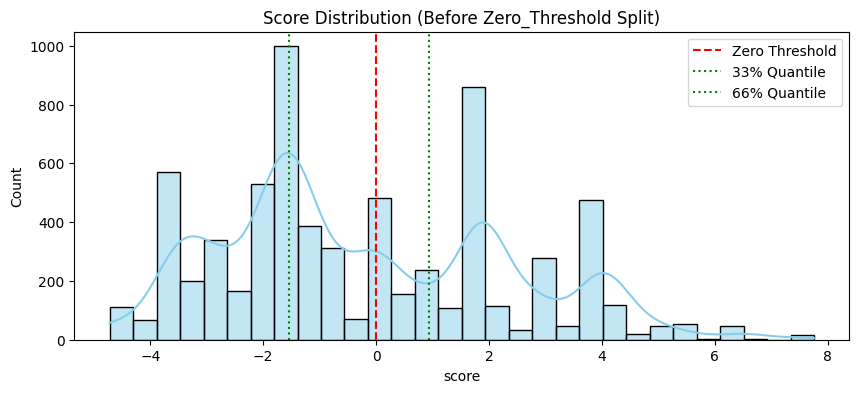

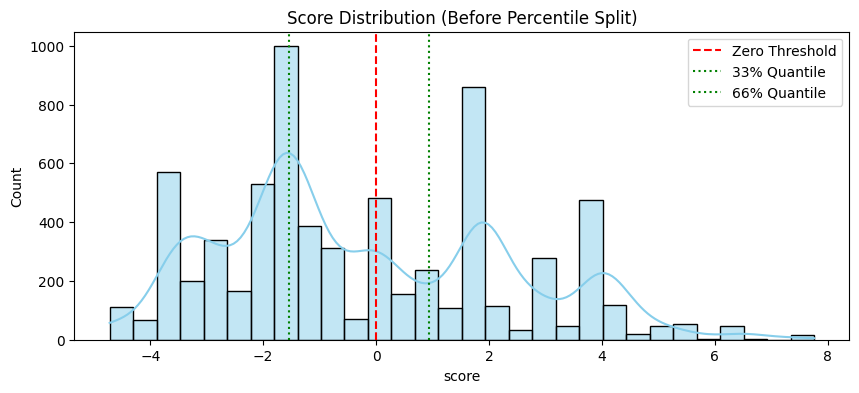

Datasets loaded successfully.


In [8]:
datasets = {}

if df_semeval_raw_train is not None and df_semeval_raw_dev is not None:
    # 1. Zero_Threshold
    datasets["Zero_Threshold"] = (get_strategy_zero_threshold(df_semeval_raw_train, visualize=True), get_strategy_zero_threshold(df_semeval_raw_dev))
    
    # 2. Percentile_Split
    d_perc_train, stats_perc = get_strategy_percentile(df_semeval_raw_train, visualize=True)
    d_perc_dev, _ = get_strategy_percentile(df_semeval_raw_dev, thresholds=stats_perc)
    datasets["Percentile_Split"] = (d_perc_train, d_perc_dev)
    
    # 3. Direct_Tags
    datasets["Direct_Tags"] = (get_strategy_direct_tags(df_semeval_raw_train), get_strategy_direct_tags(df_semeval_raw_dev))
    
    print("Datasets loaded successfully.")
else:
    print("Critical Error: Data could not be loaded. Exiting pipeline.")

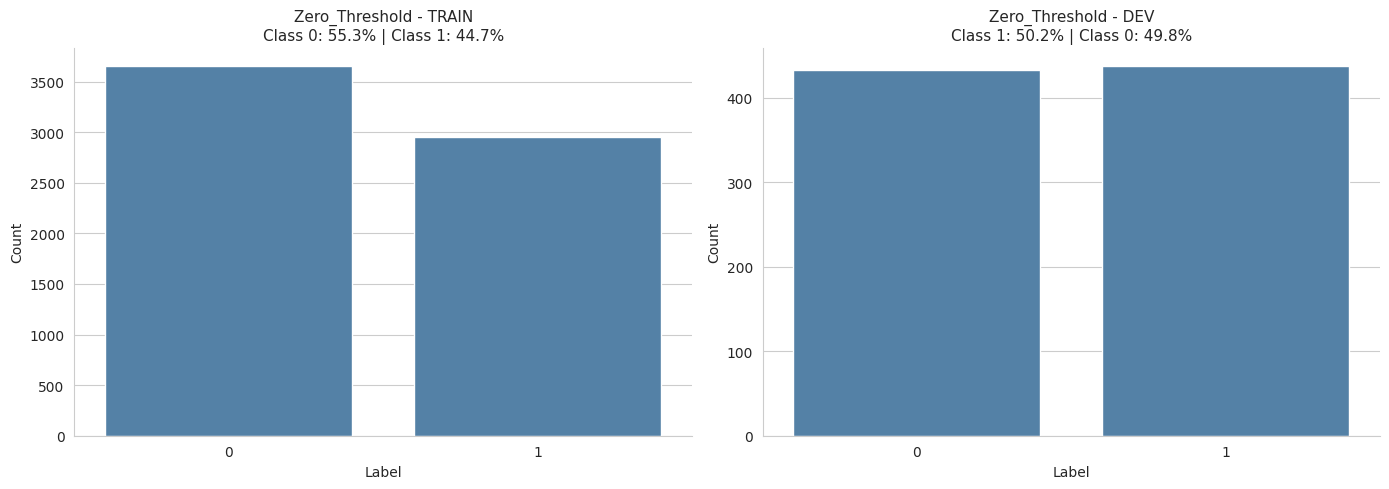

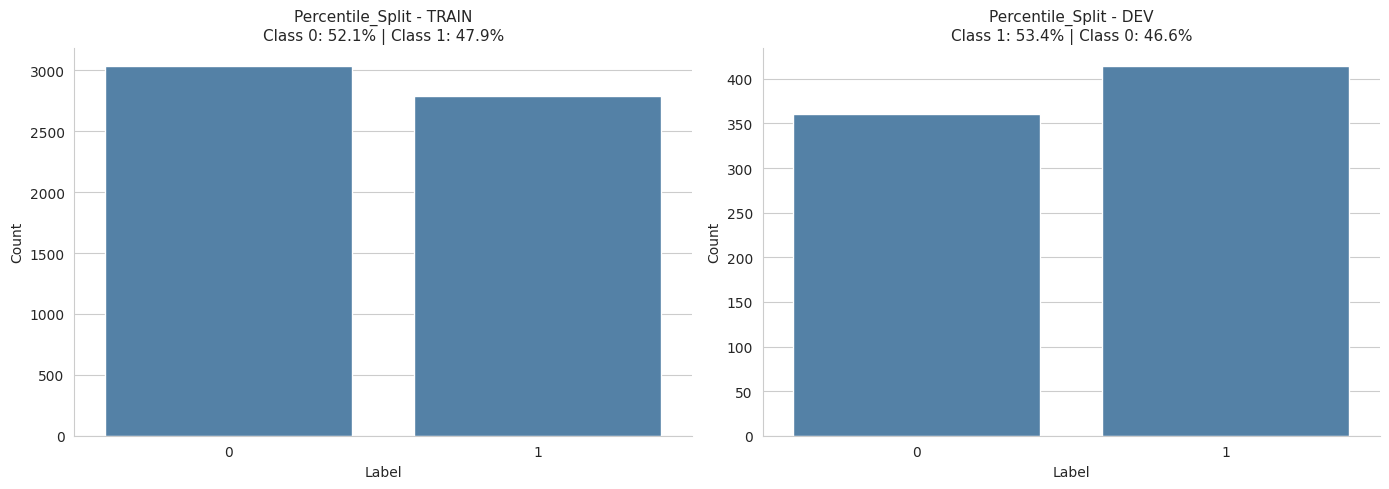

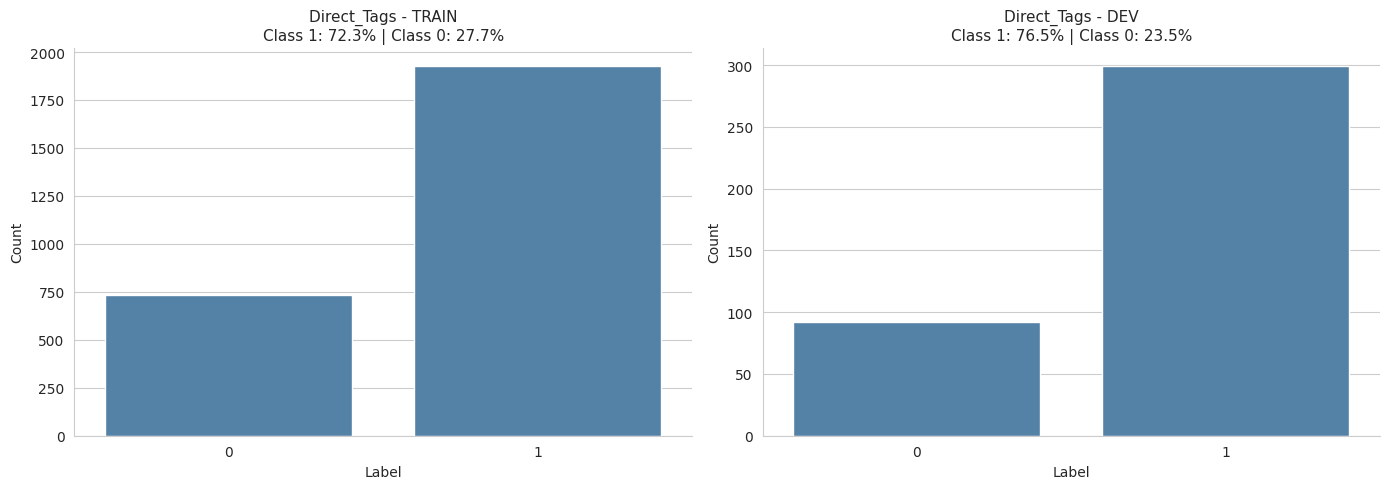

In [9]:
def plot_dataset_distributions(datasets_dict, target_col='label'):
    """
    Generates simple (monochrome) histograms for each strategy.
    """
    if not datasets_dict:
        print("No datasets available to visualize.")
        return
    sns.set_style("whitegrid")

    for strategy_name, (df_train, df_dev) in datasets_dict.items():
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        base_color = 'steelblue'

        # Plot for TRAIN
        if target_col in df_train.columns:
            sns.countplot(data=df_train, x=target_col, ax=axes[0], color=base_color)
            
            counts = df_train[target_col].value_counts(normalize=True)
            info_str = " | ".join([f"Class {k}: {v:.1%}" for k, v in counts.items()])
            axes[0].set_title(f"{strategy_name} - TRAIN\n{info_str}", fontsize=11)
            axes[0].set_ylabel("Count")
            axes[0].set_xlabel("Label")
        else:
            axes[0].text(0.5, 0.5, "Missing column", ha='center')

        # Plot for DEV
        if target_col in df_dev.columns:
            sns.countplot(data=df_dev, x=target_col, ax=axes[1], color=base_color)
            
            counts = df_dev[target_col].value_counts(normalize=True)
            info_str = " | ".join([f"Class {k}: {v:.1%}" for k, v in counts.items()])
            axes[1].set_title(f"{strategy_name} - DEV\n{info_str}", fontsize=11)
            axes[1].set_ylabel("Count")
            axes[1].set_xlabel("Label")
        else:
            axes[1].text(0.5, 0.5, "Missing column", ha='center')

        sns.despine()
        plt.tight_layout()
        plt.show()

plot_dataset_distributions(datasets, target_col='label')

## PREPROCESSING

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def prep_minimal(text):
    """Minimal preprocessing: URL removal and unicode normalization."""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = " ".join(text.split())
    text = unicodedata.normalize('NFKC', text)
    return text.strip()

def prep_specific_tfidf(text):
    """
    Standard preprocessing for TF-IDF/Bag-of-Words models.
    Includes lemmatization and stopword removal.
    """
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.lower()
    text = re.sub(r'@\w+', 'USER', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    clean = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(clean)

def prep_specific_textcnn(text):
    """Preprocessing for TextCNN: preserves structure but masks entities."""
    text = re.sub(r'http\S+|www\S+', '<URL>', text)
    text = re.sub(r'@\w+', '<USER>', text)
    return text

def prep_specific_distilbert(text):
    text = " ".join(text.split())
    return text.lower()

def prep_specific_bertweet(text):
    """Specific preprocessing rules for BERTweet (USER, HTTPURL placeholders)."""
    text = re.sub(r'@\w+', '@USER', text)
    text = re.sub(r'http\S+|www\S+', 'HTTPURL', text)
    return text

# Save Model to Disk
def save_artifact_to_disk(artifact, config_id):
    """Saves the trained model and vectorizer/tokenizer to disk."""
    path = os.path.join(MODELS_DIR, config_id)
    if not os.path.exists(path):
        os.makedirs(path)
    
    print(f"Saving model to {path}...")
    
    if artifact['type'] == 'sklearn':
        joblib.dump(artifact['model'], os.path.join(path, "model.pkl"))
        joblib.dump(artifact['vectorizer'], os.path.join(path, "vectorizer.pkl"))
        
    elif artifact['type'] == 'trans':
        artifact['trainer'].save_model(path)
        artifact['tokenizer'].save_pretrained(path)
        
    with open(os.path.join(path, "config.txt"), "w") as f:
        f.write(f"Model: {artifact.get('meta_model')}\n")
        f.write(f"Prep: {artifact.get('meta_prep')}\n")

# Error Analysis
def analyze_errors(y_true, y_pred, texts, title="Error Analysis"):
    """Plots confusion matrix and prints FULL example errors."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Optimist', 'Optimist'], yticklabels=['Non-Optimist', 'Optimist'])
    plt.title(f"Confusion Matrix: {title}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    df_err = pd.DataFrame({'text': texts, 'true': y_true, 'pred': y_pred})
    
    # Filter specific error types
    fp = df_err[(df_err['pred'] == 1) & (df_err['true'] == 0)].head(3)
    fn = df_err[(df_err['pred'] == 0) & (df_err['true'] == 1)].head(3)
    
    if not fp.empty:
        print("Sample False Positives (Incorrectly predicted as Optimist):")
        for t in fp['text'].values: 
            print(f" - {t}")
            print("")

    if not fn.empty:
        print("Sample False Negatives (Missed Optimism):")
        for t in fn['text'].values: 
            print(f" - {t}")
            print("")

## MODEL IMPLEMENTATIONS

In [11]:
# SKLEARN IMPLEMENTATION
def train_sklearn_tuned(model_type, train_df, dev_df, prep_func):
    """Trains LR or SVM using GridSearchCV."""
    print(f"Starting Preprocessing and Vectorization ({model_type})...")
    X_train = train_df['Tweet'].apply(prep_func)
    X_dev = dev_df['Tweet'].apply(prep_func)
    y_train = train_df['label']
    y_dev = dev_df['label']

    vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9, max_features=50000)
    X_train_vec = vec.fit_transform(X_train)
    X_dev_vec = vec.transform(X_dev)

    if model_type == "LR":
        param_grid = {'C': [0.1, 0.5, 1, 5, 10]}
        base_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
    else: # SVM
        param_grid = {'C': [0.1, 0.5, 1, 5, 10], 'kernel': ['linear', 'rbf']}
        base_clf = SVC(class_weight='balanced', random_state=SEED)

    grid = GridSearchCV(base_clf, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_vec, y_train)

    best_clf = grid.best_estimator_
    preds = best_clf.predict(X_dev_vec)
    f1 = f1_score(y_dev, preds, average='macro')
    
    return f1, best_clf, vec, preds

# TEXTCNN IMPLEMENTATION
class CNN_Dataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.texts = texts; self.labels = labels; self.vocab = vocab; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        tokens = self.texts[idx].split()
        ids = [self.vocab.get(t, 1) for t in tokens][:self.max_len]
        if len(ids) < self.max_len: ids += [0] * (self.max_len - len(ids))
        return torch.tensor(ids), torch.tensor(self.labels[idx])

class TextCNN_Model(nn.Module):
    """Basic 1D Convolutional Neural Network for text classification."""
    def __init__(self, vocab_size, embed_dim=100):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 3 parallel filters with window sizes 3, 4, and 5
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, 100, k) for k in [3,4,5]])
        self.fc = nn.Linear(300, 2)
        self.drop = nn.Dropout(0.5)
    def forward(self, x):
        x = self.emb(x).permute(0,2,1)
        x = [F.relu(c(x)) for c in self.convs]
        x = [F.max_pool1d(i, i.shape[2]).squeeze(2) for i in x]
        return self.fc(self.drop(torch.cat(x, 1)))

def train_textcnn_runner(train_df, dev_df, prep_func):
    """Training loop for TextCNN with manual Early Stopping."""
    train_txt = train_df['Tweet'].apply(prep_func).tolist()
    dev_txt = dev_df['Tweet'].apply(prep_func).tolist()
    y_train = train_df['label'].values
    
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

    # Build Vocabulary
    ctr = Counter()
    for t in train_txt: ctr.update(t.split())
    vocab = {"<PAD>":0, "<UNK>":1}
    idx = 2
    for w,c in ctr.items():
        if c>=2: vocab[w]=idx; idx+=1

    train_ds = CNN_Dataset(train_txt, train_df['label'].tolist(), vocab)
    dev_ds = CNN_Dataset(dev_txt, dev_df['label'].tolist(), vocab)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
    dev_dl = DataLoader(dev_ds, batch_size=32)

    model = TextCNN_Model(len(vocab)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss(weight=weights_tensor)

    best_f1 = 0.0
    patience = 3; patience_counter = 0

    for ep in range(15):
        model.train()
        for bx, by in train_dl:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            opt.zero_grad(); loss = crit(model(bx), by); loss.backward(); opt.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for bx, _ in dev_dl:
                preds.extend(torch.argmax(model(bx.to(DEVICE)), 1).cpu().numpy())
        val_f1 = f1_score(dev_df['label'], preds, average='macro')

        if val_f1 > best_f1:
            best_f1 = val_f1; patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break
    return best_f1

# TRANSFORMERS IMPLEMENTATION
def compute_metrics(p):
    """Metric computation for Hugging Face Trainer."""
    return {"f1_macro": f1_score(p.label_ids, np.argmax(p.predictions, axis=1), average='macro')}

## SEMEVAL EXPERIMENTS


=== PHASE 1: SEMEVAL TRAINING EXPERIMENTS ===

Running experiment: Model=LR | Prep=Minimal | Dataset=Zero_Threshold
Starting Preprocessing and Vectorization (LR)...
SemEval F1 Score: 0.7631


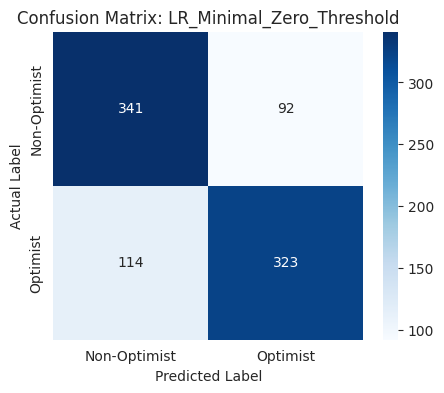

Sample False Positives (Incorrectly predicted as Optimist):
 - @RanaAyyub @rajnathsingh Oh, hidden revenge and anger...I rememberthe time,she rebutted you.

 - My best friends driving for the first time with me in the car #terrifying

 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=LR | Prep=Minimal | Dataset=Percentile_Split
Starting Preprocessing and Vectorization (LR)...
SemEval F1 Score: 0.7812


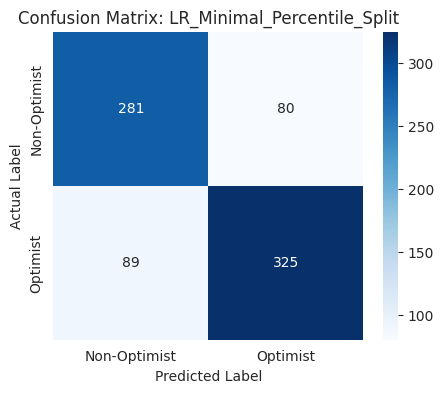

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - @3lectric5heep Well that must sting doesn't it @CNN ?

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=LR | Prep=Minimal | Dataset=Direct_Tags
Starting Preprocessing and Vectorization (LR)...
SemEval F1 Score: 0.7558


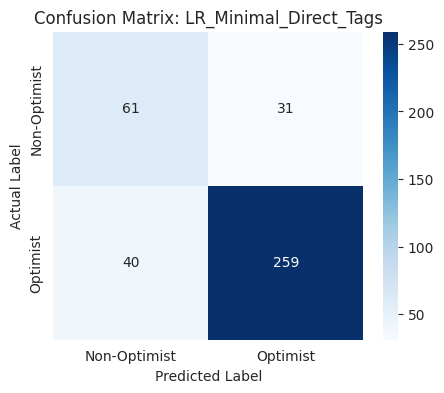

Sample False Positives (Incorrectly predicted as Optimist):
 - That moment when you look back and realise you've been a #selfish #horrible #judgemental person. #FeelingAshamed

 - @virtualalien there are more #frightening things in life\n\n#BeyondTheSphereOfReasonableDoubt

 - I feel exhausted ...\nI tried to do a good job, but apparently God does not see me right. I'm weary! I EXIST! 😟💔📢\n#exist #weary #misonorotta

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=LR | Prep=Specific (TF-IDF) | Dataset=Zero_Threshold
Starting Preprocessing and Vectorization (LR)...
SemEval F1 Score: 0.7724


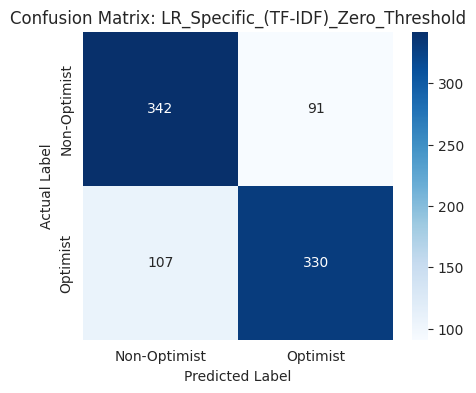

Sample False Positives (Incorrectly predicted as Optimist):
 - @RanaAyyub @rajnathsingh Oh, hidden revenge and anger...I rememberthe time,she rebutted you.

 - My best friends driving for the first time with me in the car #terrifying

 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=LR | Prep=Specific (TF-IDF) | Dataset=Percentile_Split
Starting Preprocessing and Vectorization (LR)...
SemEval F1 Score: 0.7892


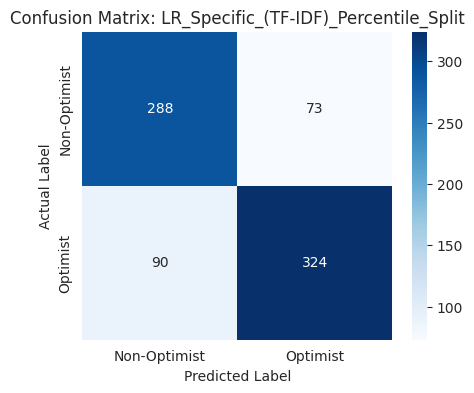

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - O, the melancholy Catacombs quickly wandered about the Rue Morgue, Madman!

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=LR | Prep=Specific (TF-IDF) | Dataset=Direct_Tags
Starting Preprocessing and Vectorization (LR)...
SemEval F1 Score: 0.7455


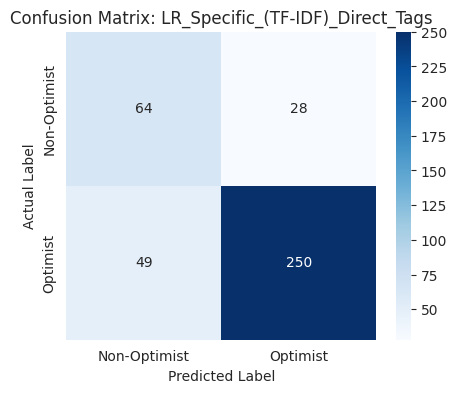

Sample False Positives (Incorrectly predicted as Optimist):
 - O, the melancholy Catacombs quickly wandered about the Rue Morgue, Madman!

 - That moment when you look back and realise you've been a #selfish #horrible #judgemental person. #FeelingAshamed

 - I feel exhausted ...\nI tried to do a good job, but apparently God does not see me right. I'm weary! I EXIST! 😟💔📢\n#exist #weary #misonorotta

Sample False Negatives (Missed Optimism):
 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved

 - You can have a certain #arrogance, and I think that's fine, but what you should never lose is the #respect for the others.


Running experiment: Model=SVM | Prep=Minimal | Dataset=Zero_Threshold
Starting Preprocessing and Vectorization (SVM)...
SemEval F1 Score: 0.7608


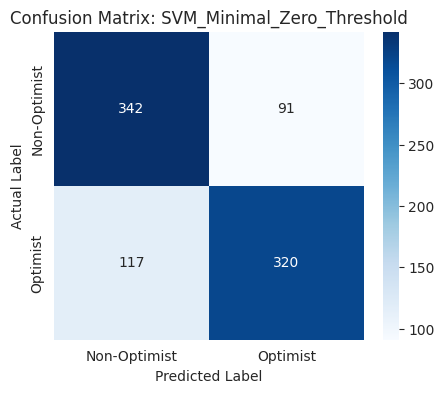

Sample False Positives (Incorrectly predicted as Optimist):
 - My best friends driving for the first time with me in the car #terrifying

 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=SVM | Prep=Minimal | Dataset=Percentile_Split
Starting Preprocessing and Vectorization (SVM)...
SemEval F1 Score: 0.7788


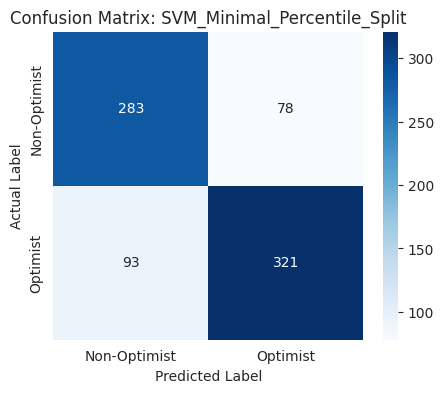

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - @3lectric5heep Well that must sting doesn't it @CNN ?

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=SVM | Prep=Minimal | Dataset=Direct_Tags
Starting Preprocessing and Vectorization (SVM)...
SemEval F1 Score: 0.7530


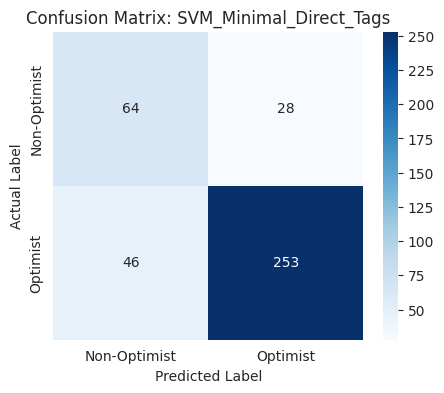

Sample False Positives (Incorrectly predicted as Optimist):
 - @virtualalien there are more #frightening things in life\n\n#BeyondTheSphereOfReasonableDoubt

 - I feel exhausted ...\nI tried to do a good job, but apparently God does not see me right. I'm weary! I EXIST! 😟💔📢\n#exist #weary #misonorotta

 - You could have over a hundred million followers and still not a genuine person who understands you or wants to #cantshakethis #sadness

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=SVM | Prep=Specific (TF-IDF) | Dataset=Zero_Threshold
Starting Preprocessing and Vectorization (SVM)...
SemEval F1 Score: 0.7732


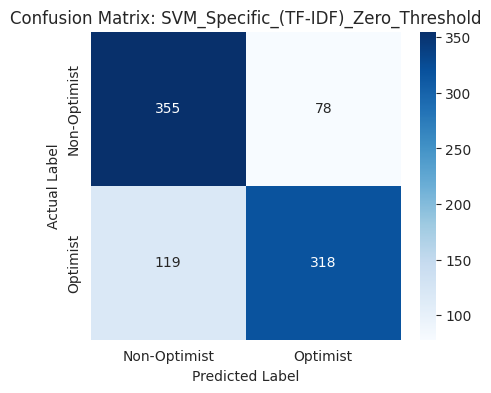

Sample False Positives (Incorrectly predicted as Optimist):
 - My best friends driving for the first time with me in the car #terrifying

 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - O, the melancholy Catacombs quickly wandered about the Rue Morgue, Madman!

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=SVM | Prep=Specific (TF-IDF) | Dataset=Percentile_Split
Starting Preprocessing and Vectorization (SVM)...
SemEval F1 Score: 0.7921


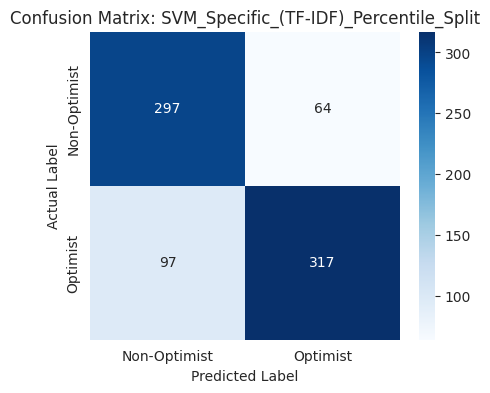

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - O, the melancholy Catacombs quickly wandered about the Rue Morgue, Madman!

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=SVM | Prep=Specific (TF-IDF) | Dataset=Direct_Tags
Starting Preprocessing and Vectorization (SVM)...
SemEval F1 Score: 0.7505


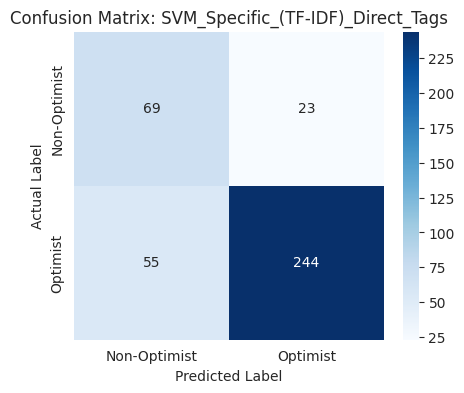

Sample False Positives (Incorrectly predicted as Optimist):
 - I feel exhausted ...\nI tried to do a good job, but apparently God does not see me right. I'm weary! I EXIST! 😟💔📢\n#exist #weary #misonorotta

 - Also 45 billion for the opiod crisis is pennies, complete joke almost as hilarious as 65 billion for high risk pools! Itll #dryupquick

 - @mysarazaman Ya it makes me be more selfish and disheartened

Sample False Negatives (Missed Optimism):
 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved

 - Brighten up a gloomy day with a @SiennaXOfficial spray tan, we have a tan to suit everybody! #spraytan #tan #summer #godalming #hurtmore


Running experiment: Model=TextCNN | Prep=Minimal | Dataset=Zero_Threshold
SemEval F1 Score: 0.6387

Running experiment: Model=TextCNN | Prep=Minimal | Dataset=Percentile_Split
SemEval F1 Score: 0.6740

Running experiment: Model=TextC

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.356415,0.845889
2,No log,0.352191,0.852377


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/DistilBERT_Minimal_Zero_Threshold...
SemEval F1 Score: 0.8494


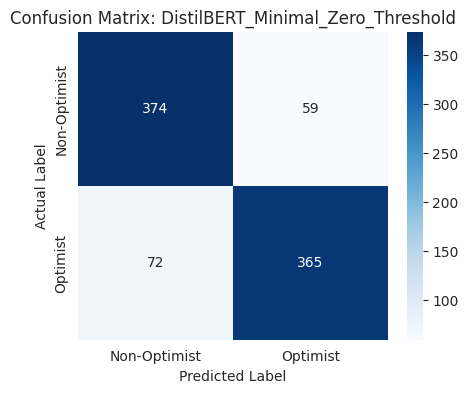

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - ...with the couple, so you decide to ignore everything and finish yours while dealing with the laughter and everything in the background.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=DistilBERT | Prep=Minimal | Dataset=Percentile_Split


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.329542,0.862015
2,No log,0.341455,0.867560


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/DistilBERT_Minimal_Percentile_Split...
SemEval F1 Score: 0.8696


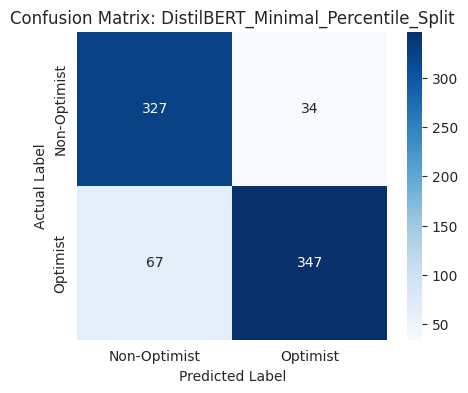

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - #Trump's only #concern is personal #profit through his #brand and doing #favors for others in trade for his own needs. Not #US #people.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=DistilBERT | Prep=Minimal | Dataset=Direct_Tags


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.439345,0.420022
2,No log,0.370718,0.799610


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/DistilBERT_Minimal_Direct_Tags...
SemEval F1 Score: 0.8378


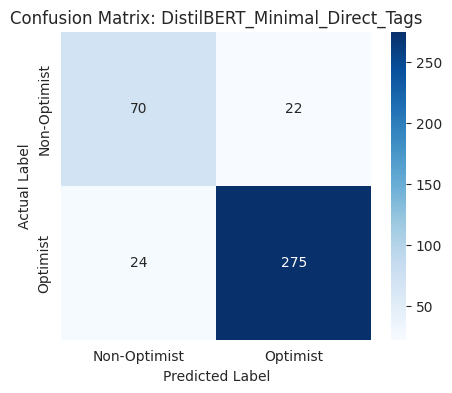

Sample False Positives (Incorrectly predicted as Optimist):
 - O, the melancholy Catacombs quickly wandered about the Rue Morgue, Madman!

 - Also 45 billion for the opiod crisis is pennies, complete joke almost as hilarious as 65 billion for high risk pools! Itll #dryupquick

 - One of the great/horrible moments as a professor is seeing a wonderful student leaving your university to pursue his/her true passion.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - thought I was a bad driver until I went to college #relieved

 - @byunsolo I DIDN'T ASK FOR THIS EITHER IT JUST HAPPENED 😤


Running experiment: Model=DistilBERT | Prep=Specific | Dataset=Zero_Threshold


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.363484,0.844491
2,No log,0.359087,0.847191


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/DistilBERT_Specific_Zero_Threshold...
SemEval F1 Score: 0.8448


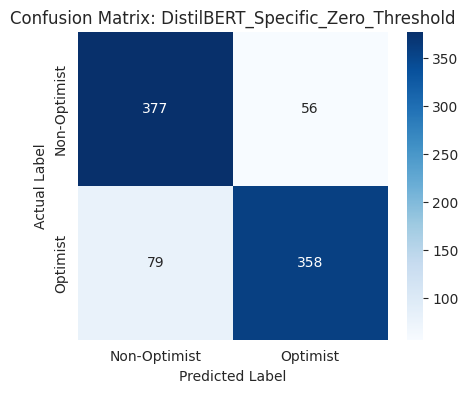

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - ...with the couple, so you decide to ignore everything and finish yours while dealing with the laughter and everything in the background.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=DistilBERT | Prep=Specific | Dataset=Percentile_Split


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.329784,0.862015
2,No log,0.341676,0.866714


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/DistilBERT_Specific_Percentile_Split...
SemEval F1 Score: 0.8683


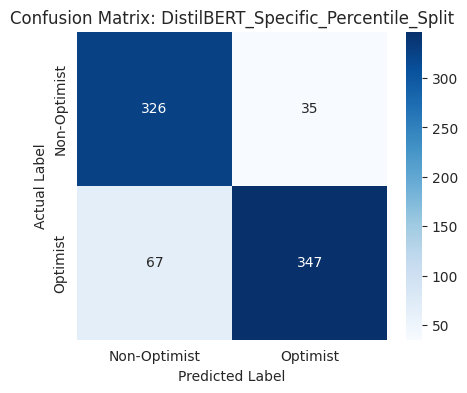

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - #Trump's only #concern is personal #profit through his #brand and doing #favors for others in trade for his own needs. Not #US #people.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - @stuael Ano man, I'm stunned! At one point our heads were gone and they were scoring at will! #relieved

 - thought I was a bad driver until I went to college #relieved


Running experiment: Model=DistilBERT | Prep=Specific | Dataset=Direct_Tags


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.439601,0.420022
2,No log,0.371811,0.799610


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/DistilBERT_Specific_Direct_Tags...
SemEval F1 Score: 0.8365


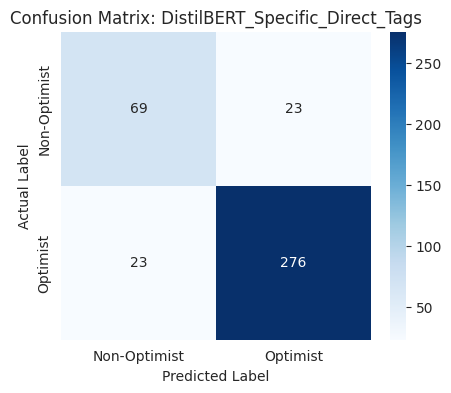

Sample False Positives (Incorrectly predicted as Optimist):
 - O, the melancholy Catacombs quickly wandered about the Rue Morgue, Madman!

 - Also 45 billion for the opiod crisis is pennies, complete joke almost as hilarious as 65 billion for high risk pools! Itll #dryupquick

 - One of the great/horrible moments as a professor is seeing a wonderful student leaving your university to pursue his/her true passion.

Sample False Negatives (Missed Optimism):
 - #LouiseLinton - haters gonna hate keep on being your#fabulous self they'll keep on being  #miserable

 - thought I was a bad driver until I went to college #relieved

 - @byunsolo I DIDN'T ASK FOR THIS EITHER IT JUST HAPPENED 😤


Running experiment: Model=BERTweet | Prep=Minimal | Dataset=Zero_Threshold


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.344937,0.860443
2,No log,0.334438,0.869484


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/BERTweet_Minimal_Zero_Threshold...
SemEval F1 Score: 0.8713


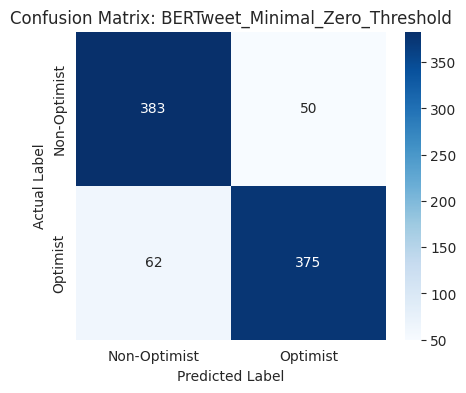

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - ...with the couple, so you decide to ignore everything and finish yours while dealing with the laughter and everything in the background.

Sample False Negatives (Missed Optimism):
 - why is everybody seem sp serious?

 - Only I could be talking to a catfish on tinder 💁😂 glad I don't use it seriously 🤣

 - #World do you know what the difference is between #drunk and #sober? One word. #Coherence.


Running experiment: Model=BERTweet | Prep=Minimal | Dataset=Percentile_Split


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.328763,0.869385
2,No log,0.286377,0.885464


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/BERTweet_Minimal_Percentile_Split...
SemEval F1 Score: 0.9005


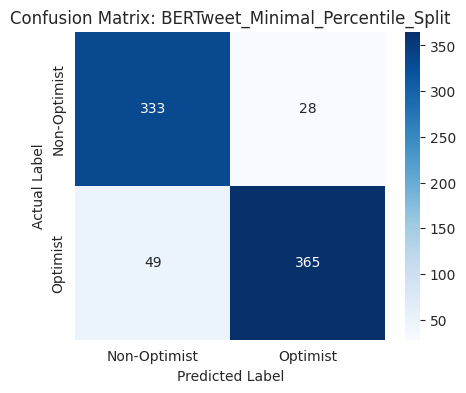

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - Happy that we played tgt as a team once. Thought there would be another chance out there but sadly no. Rest In Peace my dear friend. :(

Sample False Negatives (Missed Optimism):
 - @byunsolo I DIDN'T ASK FOR THIS EITHER IT JUST HAPPENED 😤

 - why is everybody seem sp serious?

 - Only I could be talking to a catfish on tinder 💁😂 glad I don't use it seriously 🤣


Running experiment: Model=BERTweet | Prep=Minimal | Dataset=Direct_Tags


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.367758,0.808109
2,No log,0.342667,0.831019


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/BERTweet_Minimal_Direct_Tags...
SemEval F1 Score: 0.8774


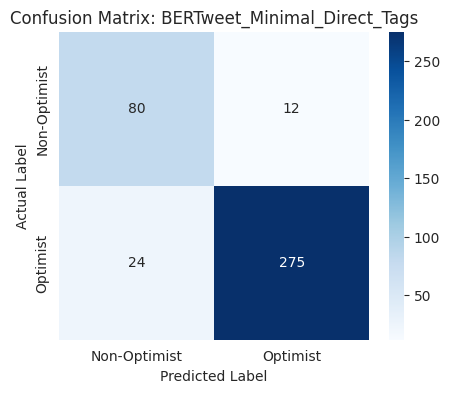

Sample False Positives (Incorrectly predicted as Optimist):
 - @virtualalien there are more #frightening things in life\n\n#BeyondTheSphereOfReasonableDoubt

 - anxiety pays off

 - @NewsByKatherine @jonkarl @ABC YOU GUY'S SOUND astounded!! Does anyone working w Trump WH have an any ethical,moral, values? 🙈🙉🙊

Sample False Negatives (Missed Optimism):
 - @TeaPainUSA He's creating tomorrow's headline. #dontgetdistracted #RussianCollusion #Partofhisplan  #TrumpRussia #ImpeachOrResign

 - smiling but we're close to tears

 - @Ginoceno Great prediction bro! Nice optimism #FAKEFAN


Running experiment: Model=BERTweet | Prep=Specific | Dataset=Zero_Threshold


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.348942,0.859423
2,No log,0.335263,0.866756


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/BERTweet_Specific_Zero_Threshold...
SemEval F1 Score: 0.8747


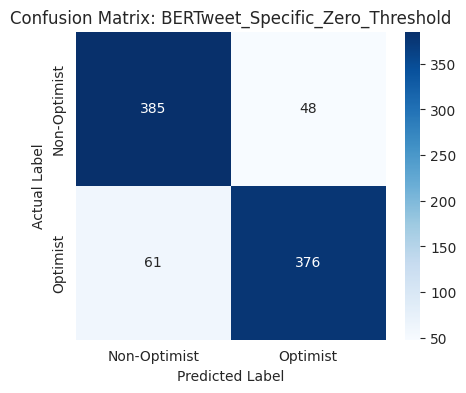

Sample False Positives (Incorrectly predicted as Optimist):
 - @ThomasEWoods I would like to hear a podcast of you going off refuting her entire article. Extra indignation please.

 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - ...with the couple, so you decide to ignore everything and finish yours while dealing with the laughter and everything in the background.

Sample False Negatives (Missed Optimism):
 - @byunsolo I DIDN'T ASK FOR THIS EITHER IT JUST HAPPENED 😤

 - why is everybody seem sp serious?

 - Only I could be talking to a catfish on tinder 💁😂 glad I don't use it seriously 🤣


Running experiment: Model=BERTweet | Prep=Specific | Dataset=Percentile_Split


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.319463,0.874450
2,No log,0.303185,0.878595


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/BERTweet_Specific_Percentile_Split...
SemEval F1 Score: 0.8991


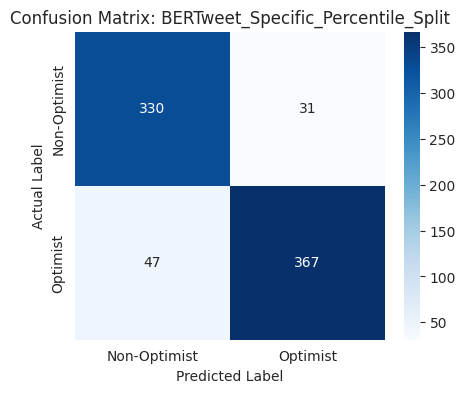

Sample False Positives (Incorrectly predicted as Optimist):
 - #RIPBiwott I think Robert oukos soul can now rejoice and rest in peace. Call an evil man evil and a good man a good man. He was an evil man

 - Happy that we played tgt as a team once. Thought there would be another chance out there but sadly no. Rest In Peace my dear friend. :(

 - There's no excuse for making the same mistakes twice. Live &amp; Learn or deal with the consequences of being unhappy #truthbomb

Sample False Negatives (Missed Optimism):
 - why is everybody seem sp serious?

 - Only I could be talking to a catfish on tinder 💁😂 glad I don't use it seriously 🤣

 - #World do you know what the difference is between #drunk and #sober? One word. #Coherence.


Running experiment: Model=BERTweet | Prep=Specific | Dataset=Direct_Tags


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.355740,0.811775
2,No log,0.340771,0.826491


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saving model to /kaggle/working/saved_models/BERTweet_Specific_Direct_Tags...
SemEval F1 Score: 0.8770


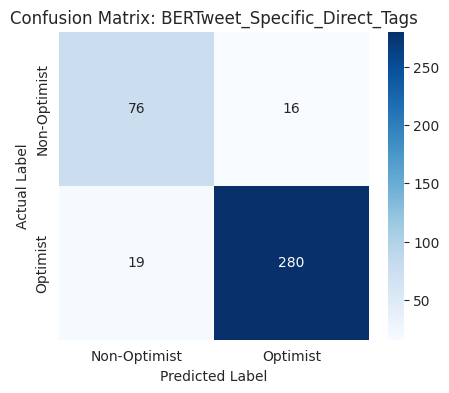

Sample False Positives (Incorrectly predicted as Optimist):
 - @virtualalien there are more #frightening things in life\n\n#BeyondTheSphereOfReasonableDoubt

 - anxiety pays off

 - @NewsByKatherine @jonkarl @ABC YOU GUY'S SOUND astounded!! Does anyone working w Trump WH have an any ethical,moral, values? 🙈🙉🙊

Sample False Negatives (Missed Optimism):
 - @TeaPainUSA He's creating tomorrow's headline. #dontgetdistracted #RussianCollusion #Partofhisplan  #TrumpRussia #ImpeachOrResign

 - smiling but we're close to tears

 - @Ginoceno Great prediction bro! Nice optimism #FAKEFAN



In [12]:
configs = [
    # (ModelName, PrepName, PrepFunc, RunnerType, ExtraArgs)
    ("LR", "Minimal", prep_minimal, "sklearn", {}),
    ("LR", "Specific (TF-IDF)", prep_specific_tfidf, "sklearn", {}),
    
    ("SVM", "Minimal", prep_minimal, "sklearn", {}),
    ("SVM", "Specific (TF-IDF)", prep_specific_tfidf, "sklearn", {}),
    
    ("TextCNN", "Minimal", prep_minimal, "cnn", {}),
    ("TextCNN", "Specific", prep_specific_textcnn, "cnn", {}),
    
    ("DistilBERT", "Minimal", prep_minimal, "trans", {"model_name": "distilbert-base-uncased"}),
    ("DistilBERT", "Specific", prep_specific_distilbert, "trans", {"model_name": "distilbert-base-uncased"}),
    
    ("BERTweet", "Minimal", prep_minimal, "trans", {"model_name": "vinai/bertweet-base"}),
    ("BERTweet", "Specific", prep_specific_bertweet, "trans", {"model_name": "vinai/bertweet-base"}),
]

results = []
dataset_names = ["Zero_Threshold", "Percentile_Split", "Direct_Tags"]
# Dictionary to store artifacts. For Transformers, we only store paths to save RAM.
trained_artifacts = {} 

print("\n=== PHASE 1: SEMEVAL TRAINING EXPERIMENTS ===")

for model_name, prep_name, prep_func, runner_type, extra_args in configs:
    for ds_name in dataset_names:

        train_df, dev_df = datasets[ds_name]
        config_id = f"{model_name}_{prep_name}_{ds_name}".replace(" ", "_")
        print(f"\nRunning experiment: Model={model_name} | Prep={prep_name} | Dataset={ds_name}")

        try:
            artifact = {}
            artifact['meta_model'] = model_name
            artifact['meta_prep'] = prep_name
            artifact['meta_dataset'] = ds_name
            artifact['config_id'] = config_id
            
            preds_dev = None

            if runner_type == "sklearn":
                f1, best_clf, vec, preds_dev = train_sklearn_tuned(model_name, train_df, dev_df, prep_func)
                artifact['model'] = best_clf
                artifact['vectorizer'] = vec
                artifact['type'] = 'sklearn'
                # Sklearn models are small enough to keep in RAM
                trained_artifacts[config_id] = artifact

            elif runner_type == "cnn":
                # CNN artifacts are not persisted in this demo to simplify code
                f1 = train_textcnn_runner(train_df, dev_df, prep_func)
                artifact['type'] = 'cnn_skip'

            elif runner_type == "trans":
                if torch.cuda.is_available():
                    # Optimization: clear cache before starting a new transformer
                    torch.cuda.empty_cache()
                    
                    tr_txt = train_df['Tweet'].apply(prep_func).tolist()
                    dv_txt = dev_df['Tweet'].apply(prep_func).tolist()
                    tok = AutoTokenizer.from_pretrained(extra_args["model_name"])

                    t_txt, v_txt, t_lbl, v_lbl = train_test_split(tr_txt, train_df['label'], test_size=0.2, random_state=SEED, stratify=train_df['label'])

                    def tokenize_fn(txts, lbls):
                        enc = tok(txts, truncation=True, padding=True, max_length=128)
                        return HFDataset.from_dict({'input_ids':enc['input_ids'], 'attention_mask':enc['attention_mask'], 'labels':lbls})

                    ds_train = tokenize_fn(t_txt, t_lbl)
                    ds_val = tokenize_fn(v_txt, v_lbl)
                    ds_test = tokenize_fn(dv_txt, dev_df['label'])

                    model = AutoModelForSequenceClassification.from_pretrained(extra_args["model_name"], num_labels=2).to(DEVICE)
                    
                    # Reduced batch size to 16 to prevent OOM
                    args = TrainingArguments(
                        output_dir=f"./temp_{config_id}",
                        eval_strategy="epoch", save_strategy="epoch",
                        learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=32,
                        num_train_epochs=2, weight_decay=0.01,
                        load_best_model_at_end=True, metric_for_best_model="f1_macro",
                        save_total_limit=1, report_to="none"
                    )

                    trainer = Trainer(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
                                      compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
                    trainer.train()

                    res = trainer.predict(ds_test)
                    preds_dev = np.argmax(res.predictions, axis=1)
                    f1 = f1_score(dev_df['label'], preds_dev, average='macro')

                    # Prepare artifact only for disk saving
                    artifact['model'] = model
                    artifact['tokenizer'] = tok
                    artifact['trainer'] = trainer
                    artifact['type'] = 'trans'
                    
                    # Save to disk
                    save_artifact_to_disk(artifact, config_id)
                    
                    # CRITICAL: Delete model from GPU memory immediately to prevent CUDA Out of Memory errors
                    del model, trainer, artifact['model'], artifact['trainer']
                    torch.cuda.empty_cache()
                    
                    # Store only the path in the artifacts dictionary, not the object itself
                    trained_artifacts[config_id] = {
                        'type': 'trans',
                        'meta_model': model_name,
                        'meta_prep': prep_name,
                        'meta_dataset': ds_name,
                        'path': os.path.join(MODELS_DIR, config_id)
                    }
                    
                    shutil.rmtree(f"./temp_{config_id}", ignore_errors=True)
                else:
                    print("Skipping Transformer (No GPU available).")
                    f1 = 0.0

            print(f"SemEval F1 Score: {f1:.4f}")
            
            # Error analysis
            if preds_dev is not None:
                if f1 > 0.4:
                    analyze_errors(dev_df['label'], preds_dev, dev_df['Tweet'], title=config_id)
                
            results.append({
                "Model": model_name,
                "Preprocessing": prep_name,
                "Train_Dataset": ds_name,
                "SemEval_F1": f1
            })

        except Exception as e:
            print(f"Exception occurred at {config_id}: {e}")
            traceback.print_exc()

## REPORTING

In [13]:
df_res = pd.DataFrame(results)
print("\nFinal SemEval Results:")
print(df_res)


Final SemEval Results:
         Model      Preprocessing     Train_Dataset  SemEval_F1
0           LR            Minimal    Zero_Threshold    0.763117
1           LR            Minimal  Percentile_Split    0.781230
2           LR            Minimal       Direct_Tags    0.755791
3           LR  Specific (TF-IDF)    Zero_Threshold    0.772370
4           LR  Specific (TF-IDF)  Percentile_Split    0.789223
5           LR  Specific (TF-IDF)       Direct_Tags    0.745471
6          SVM            Minimal    Zero_Threshold    0.760767
7          SVM            Minimal  Percentile_Split    0.778823
8          SVM            Minimal       Direct_Tags    0.753039
9          SVM  Specific (TF-IDF)    Zero_Threshold    0.773153
10         SVM  Specific (TF-IDF)  Percentile_Split    0.792120
11         SVM  Specific (TF-IDF)       Direct_Tags    0.750540
12     TextCNN            Minimal    Zero_Threshold    0.638679
13     TextCNN            Minimal  Percentile_Split    0.674013
14     TextCNN  

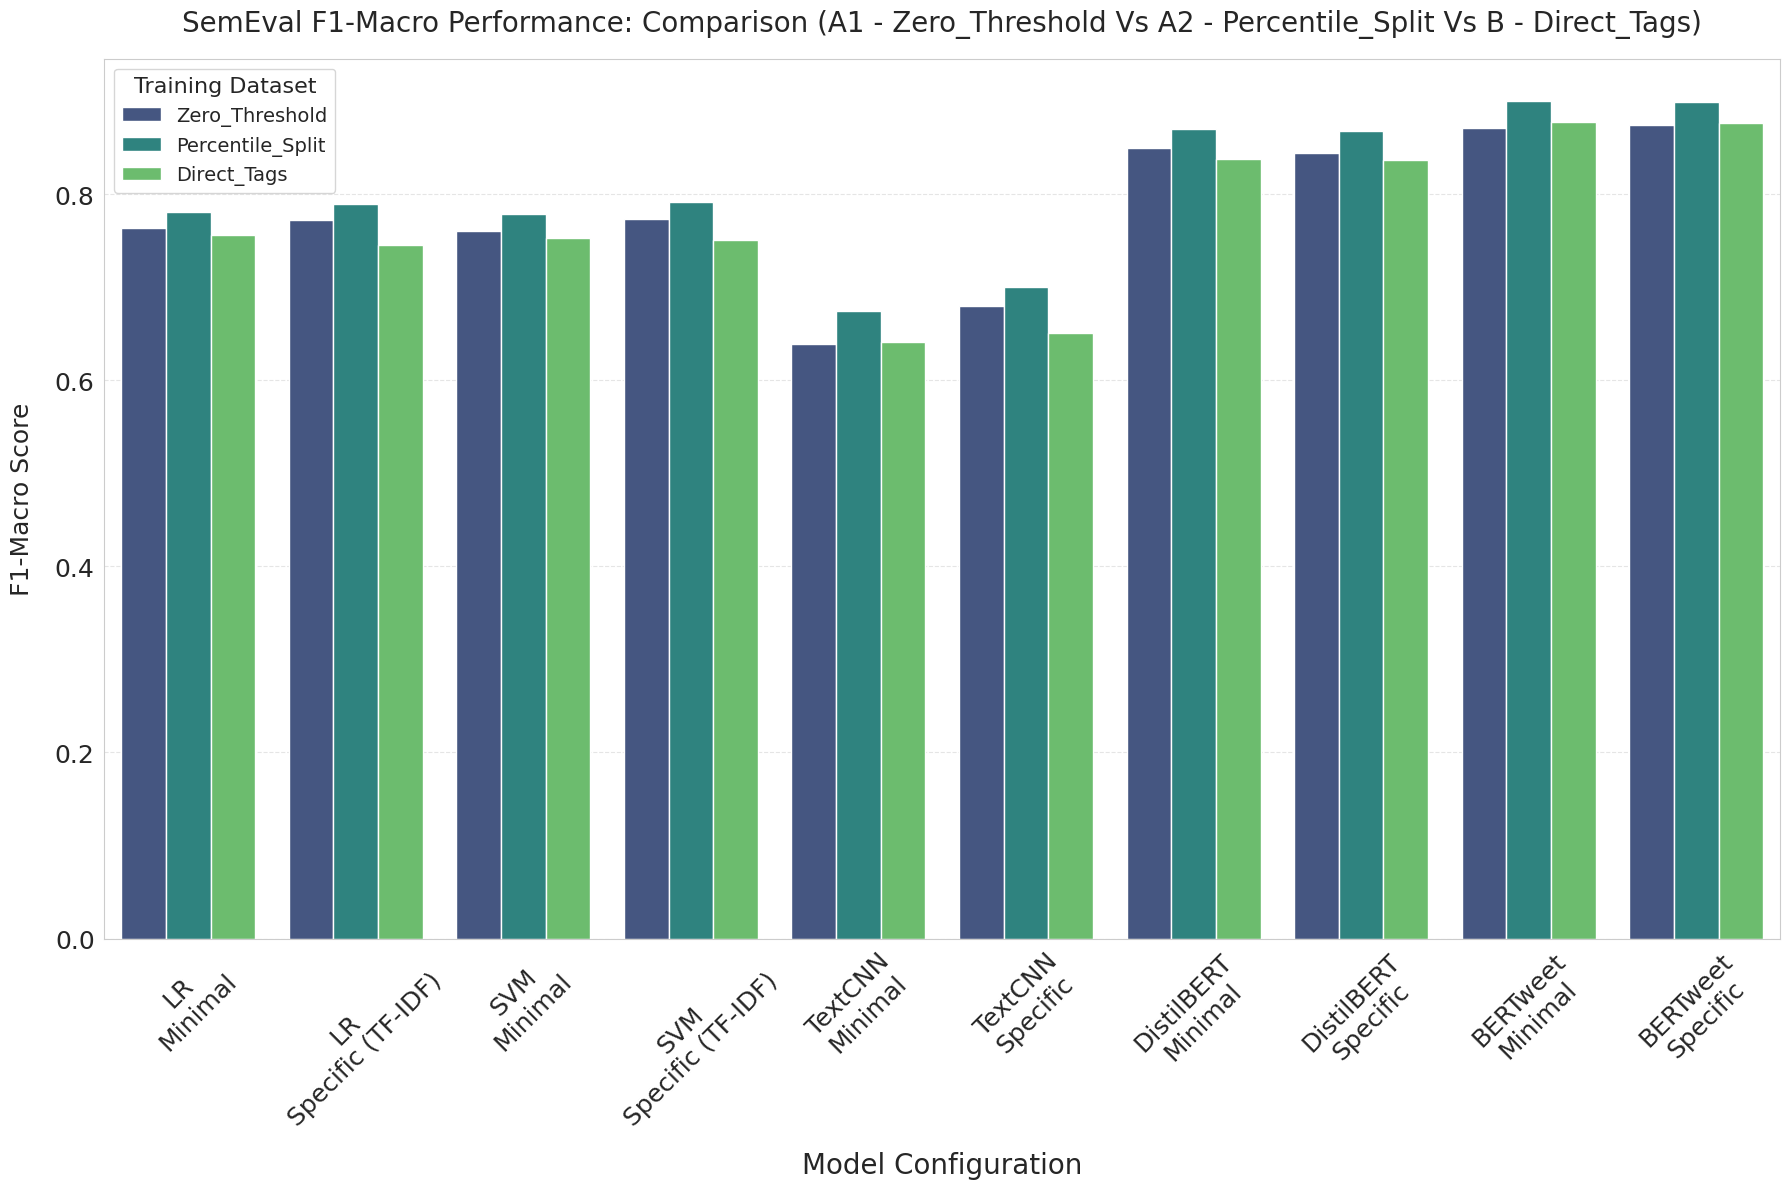

In [74]:
df_res = pd.DataFrame(results)
df_res.to_csv("final_nlp_results.csv", index=False)

# Barplot Comparison
plt.figure(figsize=(18, 12)) # Increased figure size to accommodate larger text
df_res['Config'] = df_res['Model'] + "\n" + df_res['Preprocessing']

# Create the plot
ax = sns.barplot(data=df_res, x='Config', y='SemEval_F1', hue='Train_Dataset', palette='viridis')

# 1. TITLE - Font size 20
plt.title("SemEval F1-Macro Performance: Comparison (A1 - Zero_Threshold Vs A2 - Percentile_Split Vs B - Direct_Tags)", fontsize=20, pad=20)

# 2. X and Y AXIS - Titles - Font size 16/20
plt.xlabel("Model Configuration", fontsize=20, labelpad=15)
plt.ylabel("F1-Macro Score", fontsize=18, labelpad=15)

# 3. AXIS TICKS (Values) - Font size 18
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=18)

# 4. LEGEND - Text size 14, Title size 16
plt.legend(title="Training Dataset", title_fontsize='16', fontsize='14', loc='upper left')

# Add grid and layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## CROSS-DATASET TESTING (DELL)

In [14]:
# --- Check Out-Of-Vocabulary (OOV) Rate ---
def check_oov_rate(vectorizer, new_texts, prep_func):
    """
    Calculates the % of tokens in the new dataset that are unknown to the TF-IDF model.
    High OOV explains why a model might fail on a new domain.
    """
    if not hasattr(vectorizer, 'vocabulary_'):
        return "N/A"
    
    vocab = set(vectorizer.vocabulary_.keys())
    
    total_tokens = 0
    unknown_tokens = 0
    
    for txt in new_texts:
        processed = prep_func(txt)
        tokens = processed.split()
        for t in tokens:
            total_tokens += 1
            if t not in vocab:
                unknown_tokens += 1
                
    if total_tokens == 0: return 0.0
    return (unknown_tokens / total_tokens) * 100

if os.path.exists(DELL_DATASET_PATH):
    print("\n=== PHASE 2: CROSS-DATASET TESTING (DELL) ===")
    try:
        df_dell_raw = load_data(DELL_DATASET_PATH, sep=',')
        
        # Calculate Dell scores (same logic as SemEval)
        sentiment_map = {'positive': 1, 'negative': -1, 'neutral': 0}
        def calc_new_score(row):
            s_val = sentiment_map.get(row['sentiment'], 0)
            e_weight = EMOTION_WEIGHTS.get(row['emotion'], 0)
            return (s_val * row['sentiment_score']) + (e_weight * row['emotion_score'])

        df_dell_raw['calc_score'] = df_dell_raw.apply(calc_new_score, axis=1)

        # Dell Labelling Strategies
        def get_dell_zero(df):
            temp = df.copy()
            def get_lbl(row):
                if row['emotion'] == 'optimism': return 1
                if row['calc_score'] > 0: return 1
                elif row['calc_score'] < 0: return 0
                else: return -1
            temp['label'] = temp.apply(get_lbl, axis=1)
            return temp[temp['label'] != -1][['Text', 'label']].reset_index(drop=True)

        def get_dell_percentile(df):
            temp = df.copy()
            q33 = temp['calc_score'].quantile(0.33)
            q66 = temp['calc_score'].quantile(0.66)
            def get_lbl(row):
                if row['emotion'] == 'optimism': return 1
                if row['calc_score'] <= q33: return 0
                elif row['calc_score'] >= q66: return 1
                else: return -1
            temp['label'] = temp.apply(get_lbl, axis=1)
            return temp[temp['label'] != -1][['Text', 'label']].reset_index(drop=True)

        new_datasets = {
            "Dell_Zero_Threshold": get_dell_zero(df_dell_raw),
            "Dell_Percentile": get_dell_percentile(df_dell_raw)
        }
        
        new_results = []
        
        for config_id, artifact in trained_artifacts.items():
            model_n = artifact['meta_model']
            prep_n = artifact['meta_prep']
            train_ds_n = artifact['meta_dataset']
            
            # Map SemEval strategy to Dell strategy
            test_target = "Dell_Zero_Threshold" if train_ds_n == "Zero_Threshold" else "Dell_Percentile"
            target_df = new_datasets[test_target]

            curr_prep_func = None
            for cfg in configs:
                if cfg[1] == prep_n: curr_prep_func = cfg[2]; break
            
            if curr_prep_func:
                X_new_txt = target_df['Text'].apply(curr_prep_func)
                y_new = target_df['label']
                preds_new = []
                oov_rate = "N/A"

                if artifact['type'] == 'sklearn':
                    # Sklearn models are available in RAM
                    oov_rate = check_oov_rate(artifact['vectorizer'], target_df['Text'], curr_prep_func)
                    preds_new = artifact['model'].predict(artifact['vectorizer'].transform(X_new_txt))
                    
                elif artifact['type'] == 'trans':
                    # --- LOAD ON DEMAND FOR TRANSFORMERS ---
                    print(f"Loading {model_n} from disk for evaluation...")
                    model_path = artifact['path']
                    
                    try:
                        # Load model temporarily
                        tok = AutoTokenizer.from_pretrained(model_path)
                        model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
                        
                        def tok_new(t): return tok(t, truncation=True, padding=True, max_length=128)
                        ds_new = HFDataset.from_dict(tok_new(X_new_txt.tolist()))
                        
                        # Manual prediction loop (lighter on memory than Trainer)
                        batch_size = 32
                        all_logits = []
                        model.eval()
                        with torch.no_grad():
                            for i in range(0, len(ds_new), batch_size):
                                batch = ds_new[i:i+batch_size]
                                input_ids = torch.tensor(batch['input_ids']).to(DEVICE)
                                attention_mask = torch.tensor(batch['attention_mask']).to(DEVICE)
                                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                                all_logits.append(outputs.logits.cpu().numpy())
                        
                        full_logits = np.concatenate(all_logits, axis=0)
                        preds_new = np.argmax(full_logits, axis=1)
                        
                        # CLEANUP: Delete immediately after use
                        del model, tok, ds_new, full_logits
                        torch.cuda.empty_cache()
                        
                    except Exception as e:
                        print(f"Failed to load/predict with {model_n}: {e}")
                        continue
                
                f1_new = f1_score(y_new, preds_new, average='macro')
                oov_str = f"{oov_rate:.2f}%" if isinstance(oov_rate, float) else "N/A"
                print(f"Cross-Eval Model: {model_n} | Train: {train_ds_n} -> Test: {test_target} | F1: {f1_new:.4f} | OOV: {oov_str}")

                new_results.append({
                    "Model": model_n, 
                    "Train_Dataset": train_ds_n,
                    "New_Dataset_F1": f1_new,
                    "OOV_Rate": oov_str
                })
        
        df_new_res = pd.DataFrame(new_results)
        print("\nFinal Cross-Dataset Results:")
        print(df_new_res)
        
    except Exception as e:
        print(f"Exception during Dell dataset processing: {e}")
        traceback.print_exc()
else:
    print("Dell dataset not found.")


=== PHASE 2: CROSS-DATASET TESTING (DELL) ===
Cross-Eval Model: LR | Train: Zero_Threshold -> Test: Dell_Zero_Threshold | F1: 0.7041 | OOV: 50.53%
Cross-Eval Model: LR | Train: Percentile_Split -> Test: Dell_Percentile | F1: 0.7718 | OOV: 50.09%
Cross-Eval Model: LR | Train: Direct_Tags -> Test: Dell_Percentile | F1: 0.6968 | OOV: 54.12%
Cross-Eval Model: LR | Train: Zero_Threshold -> Test: Dell_Zero_Threshold | F1: 0.6656 | OOV: 48.32%
Cross-Eval Model: LR | Train: Percentile_Split -> Test: Dell_Percentile | F1: 0.7302 | OOV: 47.19%
Cross-Eval Model: LR | Train: Direct_Tags -> Test: Dell_Percentile | F1: 0.6871 | OOV: 57.95%
Cross-Eval Model: SVM | Train: Zero_Threshold -> Test: Dell_Zero_Threshold | F1: 0.7080 | OOV: 50.53%
Cross-Eval Model: SVM | Train: Percentile_Split -> Test: Dell_Percentile | F1: 0.7718 | OOV: 50.09%
Cross-Eval Model: SVM | Train: Direct_Tags -> Test: Dell_Percentile | F1: 0.7025 | OOV: 54.12%
Cross-Eval Model: SVM | Train: Zero_Threshold -> Test: Dell_Zero_Thr

## EXPLAINABILITY (LR Interpretation)

/tmp/ipykernel_55/4130697165.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_opt, x='coef', y='word', palette='Greens_r')
/tmp/ipykernel_55/4130697165.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pes, x='coef', y='word', palette='Reds')


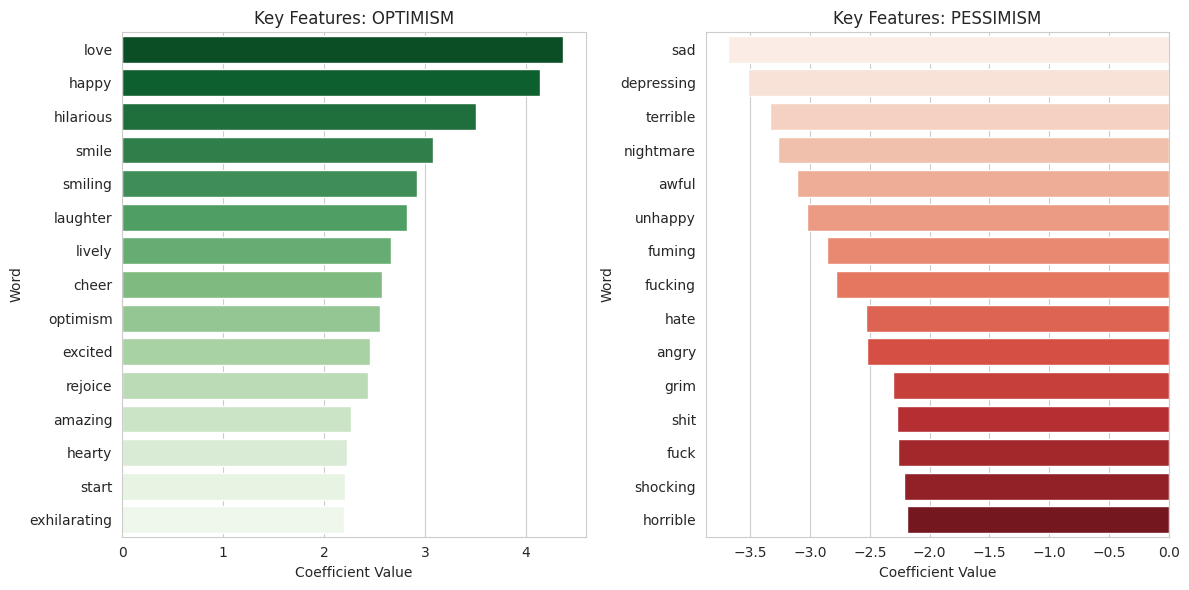

In [41]:
def plot_explainability(config_id_lr="LR_Specific_(TF-IDF)_Percentile_Split"):
    # Check if the configuration ID exists in the trained artifacts dictionary
    if config_id_lr not in trained_artifacts:
        print(f"Configuration {config_id_lr} was not found.")
        return
    
    # Retrieve the model and vectorizer from the artifact
    artifact = trained_artifacts[config_id_lr]
    model = artifact['model']
    vectorizer = artifact['vectorizer']
    
    # Get the feature names (words) from the TF-IDF vectorizer
    feature_names = vectorizer.get_feature_names_out()
    # Get the coefficients for the Logistic Regression model
    coefficients = model.coef_[0]
    
    # Create a DataFrame to map words to their respective importance (coefficients)
    feat_importances = pd.DataFrame({'word': feature_names, 'coef': coefficients})
    
    # Top 15 features for Optimism (highest positive coefficients)
    top_opt = feat_importances.sort_values(by='coef', ascending=False).head(15)
    # Top 15 features for Pessimism (lowest negative coefficients)
    top_pes = feat_importances.sort_values(by='coef', ascending=True).head(15)

    plt.figure(figsize=(12, 6))
    
    # Plotting Top Keywords for Optimism
    plt.subplot(1, 2, 1)
    sns.barplot(data=top_opt, x='coef', y='word', palette='Greens_r')
    plt.title("Key Features: OPTIMISM")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Word")
    
    # Plotting Top Keywords for Pessimism
    plt.subplot(1, 2, 2)
    sns.barplot(data=top_pes, x='coef', y='word', palette='Reds')
    plt.title("Key Features: PESSIMISM")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Word")
    
    plt.tight_layout()
    plt.show()

plot_explainability("LR_Specific_(TF-IDF)_Percentile_Split")